In [9]:
import os

In [10]:
import sys


In [14]:
os.getcwd()

'/home/sagemaker-user/reproducible/ModelWorkflow'

In [ ]:
import mlflow

mlflow.set_experiment("Download Images")
with mlflow.start_run(run_name="Download Images"):
    # Seu código para baixar imagensl
    mlflow.log_param("source", "satellite_api")
    mlflow.log_artifact("../data/raw/images", artifact_path="images")
    mlflow.log_param("input", "URLs or API endpoints for satellite images")
    mlflow.log_param("output", "Directory containing downloaded satellite images: ../data/raw/images/")
    mlflow.set_tag("aws_instance_type", "2vCPU + 8 GiB")

In [2]:
# !pip install --upgrade certifi
# !pip install google-colab
# pip install --use-pep517 google-colab
# pip install google-colab

# from google.colab import drive
# drive.mount("/content/drive",force_remount = True)

# %cd drive/Shareddrives/'NEXUS-PARSEC - TCCs'/ProjetoRaf-Car-Igor/data/indicadores_IDH_Nexus

In [ ]:
!pip install tqdm geopandas

In [4]:
import geopandas

In [5]:
from os import listdir
import glob
import pandas
import geopandas
geo = geopandas.read_file('../data/raw/setores_shapefile/ac_setores_censitarios/12SEE250GC_SIR.shp')
geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ID          900 non-null    int64   
 1   CD_GEOCODI  900 non-null    object  
 2   TIPO        900 non-null    object  
 3   CD_GEOCODB  0 non-null      object  
 4   NM_BAIRRO   0 non-null      object  
 5   CD_GEOCODS  900 non-null    object  
 6   NM_SUBDIST  0 non-null      object  
 7   CD_GEOCODD  900 non-null    object  
 8   NM_DISTRIT  900 non-null    object  
 9   CD_GEOCODM  900 non-null    object  
 10  NM_MUNICIP  900 non-null    object  
 11  NM_MICRO    900 non-null    object  
 12  NM_MESO     900 non-null    object  
 13  geometry    900 non-null    geometry
dtypes: geometry(1), int64(1), object(12)
memory usage: 98.6+ KB


In [6]:
MERCATOR_CRS = "EPSG:3857"  # Mercator projection CRS.
METRIC_CRS = {"proj":"cea"} # Metric CRS. Useful for calculations
WGS84_CRS = "EPSG:4326"     # World Geodetic System
SIRGAS_CRS = "EPSG:4674"    # SIRGAS 2000, a projection for LATAM

PLOT_CRS = MERCATOR_CRS

In [7]:
shapefiles_list = glob.glob('../data/raw/setores_shapefile/*/*.shp')
geo = geopandas.read_file(shapefiles_list[0])

from tqdm import tqdm
for file in tqdm(shapefiles_list[1:]):
    geoaux = geopandas.read_file(file)
    geo = pandas.concat([geo,geoaux],ignore_index = True)

100%|██████████| 26/26 [01:41<00:00,  3.92s/it]


In [8]:
geo = geo.to_crs(WGS84_CRS)

In [9]:
geo = geo.rename(columns ={'CD_GEO CODI':'Cod_setor','CD_GEOCODM' : 'Cod_municipio'})
geo = geo.astype({'Cod_municipio' : 'int64'})
geo = geo.drop(columns = ['ID','CD_GEOCODB','NM_BAIRRO','CD_GEOCODS','NM_SUBDIST','CD_GEOCODD'])
geo = geo.drop(columns = ['NM_DISTRIT','NM_MUNICIP','NM_MICRO','NM_MESO','ID1'])
geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 316574 entries, 0 to 316573
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   CD_GEOCODI     316574 non-null  object  
 1   TIPO           316574 non-null  object  
 2   Cod_municipio  316574 non-null  int64   
 3   geometry       316574 non-null  geometry
dtypes: geometry(1), int64(1), object(2)
memory usage: 9.7+ MB


In [10]:
geo['centroid'] = geo['geometry'].centroid
# #Extract lat and lon from the centerpoint
geo["lat"] = geo['centroid'].map(lambda p: p.x)
geo["lon"] = geo['centroid'].map(lambda p: p.y)
geo['area'] = geo['geometry'].area*1.25e4

#'import math
cod_municipio = geo['Cod_municipio']
cod_estado = (cod_municipio/100000)
cod_estado = cod_estado.astype('int64')
geo['Cod_estado'] = (cod_estado)

geo = geo.assign(year = 2010)

/tmp/ipykernel_21/4081812036.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geo['centroid'] = geo['geometry'].centroid
/tmp/ipykernel_21/4081812036.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geo['area'] = geo['geometry'].area*1.25e4


In [11]:
geo

,CD_GEOCODI,TIPO,Cod_municipio,geometry,centroid,lat,lon,area,Cod_estado,year
0,220020205000009,URBANO,2200202,"POLYGON ((-42.64497 -5.89213, -42.64418 -5.891...",POINT (-42.64554 -5.89625),-42.645535,-5.896255,0.581898,22,2010
1,220020205000010,URBANO,2200202,"POLYGON ((-42.64189 -5.89531, -42.64284 -5.893...",POINT (-42.64211 -5.89251),-42.642112,-5.892509,0.150797,22,2010
2,220020205000011,URBANO,2200202,"POLYGON ((-42.64029 -5.88399, -42.64256 -5.888...",POINT (-42.64610 -5.88854),-42.646105,-5.888541,0.760968,22,2010
3,220020205000012,URBANO,2200202,"POLYGON ((-42.64029 -5.88399, -42.63836 -5.880...",POINT (-42.63301 -5.88493),-42.633009,-5.884933,1.497101,22,2010
4,220020205000013,URBANO,2200202,"POLYGON ((-42.62941 -5.89072, -42.62947 -5.891...",POINT (-42.63064 -5.89265),-42.630635,-5.892648,0.104057,22,2010
...,...,...,...,...,...,...,...,...,...,...
316569,231410225000006,RURAL,2314102,"POLYGON ((-41.15081 -3.69669, -41.15011 -3.695...",POINT (-41.11066 -3.68188),-41.110662,-3.681883,33.033201,23,2010
316570,231410225000007,URBANO,2314102,"POLYGON ((-41.06812 -3.67289, -41.06719 -3.673...",POINT (-41.06739 -3.67465),-41.067393,-3.674653,0.074331,23,2010
316571,231410225000008,RURAL,2314102,"POLYGON ((-41.06597 -3.67783, -41.06623 -3.676...",POINT (-41.05244 -3.65986),-41.052438,-3.659861,4.896213,23,2010
316572,231410225000009,RURAL,2314102,"POLYGON ((-41.09994 -3.62549, -41.09974 -3.625...",POINT (-41.08185 -3.64671),-41.081849,-3.646706,7.803151,23,2010


# Notebook 2

# Merge NEXUS data
## Description
This notebook merges the geographic data of NEXUS census tracts with its indicator values. Then, it clears that dataset, excluding all samples that have at least one indicator as null, unknown or off the interval (0,1].
## Inputs
`NEXUS_census_tracts_2010.csv`: dataset containing the geographic data of each census tract in the NEXUS area.

`IDM_NEXUS_{state acronym}.csv`: 19 datasets, one for each state acronym, containing indicator target values of each census tract in the NEXUS area.

## Outputs
`NEXUS_data_2010.csv`: dataset containing the geographic data and indicator target values of each census tract within the NEXUS area.

# Configs

## Libraries

In [12]:
import glob
import pandas as pd
import geopandas as gpd

## Projection constants

In [13]:
MERCATOR_CRS = "EPSG:3857"  # Mercator projection CRS.
METRIC_CRS = {"proj":"cea"} # Metric CRS. Useful for calculations
WGS84_CRS = "EPSG:4326"     # World Geodetic System
SIRGAS_CRS = "EPSG:4674"    # SIRGAS 2000, a projection for LATAM

PLOT_CRS = MERCATOR_CRS

# Execution

## Read input data

### Read geographic dataset

In [14]:
#geodf_census_tracts = gpd.read_file("../data/interim/NEXUS_tracts_2010.csv") #, encoding = "iso-8859-1"
geodf_census_tracts = geo

In [15]:
# from shapely.wkt import loads
# geodf_census_tracts.geometry =  geodf_census_tracts['geometry_aux'].apply(loads)

In [16]:
geo_backup = geodf_census_tracts.copy()

In [17]:
#!! pode inverter aqui
#geodf_census_tracts = geodf_census_tracts.set_crs(WGS84_CRS) 
geodf_census_tracts = geodf_census_tracts.to_crs(MERCATOR_CRS) 

In [18]:
geodf_census_tracts.head()

,CD_GEOCODI,TIPO,Cod_municipio,geometry,centroid,lat,lon,area,Cod_estado,year
0,220020205000009,URBANO,2200202,"POLYGON ((-4747216.723 -657068.178, -4747128.4...",POINT (-42.64554 -5.89625),-42.645535,-5.896255,0.581898,22,2010
1,220020205000010,URBANO,2200202,"POLYGON ((-4746873.252 -657424.194, -4746979.1...",POINT (-42.64211 -5.89251),-42.642112,-5.892509,0.150797,22,2010
2,220020205000011,URBANO,2200202,"POLYGON ((-4746695.203 -656156.927, -4746948.4...",POINT (-42.64610 -5.88854),-42.646105,-5.888541,0.760968,22,2010
3,220020205000012,URBANO,2200202,"POLYGON ((-4746695.203 -656156.927, -4746480.9...",POINT (-42.63301 -5.88493),-42.633009,-5.884933,1.497101,22,2010
4,220020205000013,URBANO,2200202,"POLYGON ((-4745484.667 -656909.736, -4745491.2...",POINT (-42.63064 -5.89265),-42.630635,-5.892648,0.104057,22,2010


In [19]:
geodf_census_tracts = geodf_census_tracts.rename(columns = {
    "CD_GEOCODI": "cod_sector",
    "CD_GEOCODM": "cod_mun",
    "TYPE": "type"
  })

In [20]:
# original
# geodf_census_tracts = geodf_census_tracts.astype({
#     "cod_sector": "int64",
#     "cod_mun": "int64"
#   })

geodf_census_tracts = geodf_census_tracts.astype({
    "cod_sector": "int64",
    "Cod_municipio": "int64"
  })

In [21]:
geodf_census_tracts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 316574 entries, 0 to 316573
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   cod_sector     316574 non-null  int64   
 1   TIPO           316574 non-null  object  
 2   Cod_municipio  316574 non-null  int64   
 3   geometry       316574 non-null  geometry
 4   centroid       316574 non-null  geometry
 5   lat            316574 non-null  float64 
 6   lon            316574 non-null  float64 
 7   area           316574 non-null  float64 
 8   Cod_estado     316574 non-null  int64   
 9   year           316574 non-null  int64   
dtypes: float64(3), geometry(2), int64(4), object(1)
memory usage: 24.2+ MB


### Read indicator dataset

In [22]:
indicator_data_paths = glob.glob("../data/raw/NexusIndicators/*.csv")
assert(len(indicator_data_paths) == 19)

In [23]:
df_indicators = pd.read_csv(indicator_data_paths[0])

In [24]:
for state_indicator_data_path in indicator_data_paths[1:]:
    df_indicators = pd.concat([
      df_indicators,
      pd.read_csv(state_indicator_data_path)
    ])

In [25]:
df_indicators = df_indicators.rename(columns = {
    "Cod_setor": "cod_sector",
    "IDHL-Setor": "longevity",
    "AlfabIDHM": "literacy",
    "RendaIDHM": "income"
  })
df_indicators = df_indicators.astype({
    "cod_sector": "int64",
  })

In [26]:
df_indicators = df_indicators[["cod_sector", "income", "literacy", "longevity"]]

In [27]:
df_indicators.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110214 entries, 0 to 504
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   cod_sector  110214 non-null  int64  
 1   income      109987 non-null  float64
 2   literacy    109899 non-null  float64
 3   longevity   110214 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 4.2 MB


## Merge datasets

In [28]:
# from shapely.wkt import loads
# geodf_census_tracts.geometry =  geodf_census_tracts['geometry_aux'].apply(loads)
#geodf_census_tracts = geodf_census_tracts.set_geometry('geometry')

In [29]:
geodf_nexus = geodf_census_tracts.merge(df_indicators, how = "outer", on = "cod_sector")

In [30]:
geodf_nexus = geodf_nexus.assign(year = 2010)

In [31]:
geodf_nexus["cod_state"] = geodf_nexus.apply(lambda x: int(x["Cod_municipio"] / 100000), axis = 1)

In [32]:
geodf_nexus

,cod_sector,TIPO,Cod_municipio,geometry,centroid,lat,lon,area,Cod_estado,year,income,literacy,longevity,cod_state
0,110001505000001,URBANO,1100015,"POLYGON ((-6902095.714 -1337634.026, -6901964....",POINT (-62.00075 -11.93360),-62.000749,-11.933599,0.447634,11,2010,NaN,NaN,NaN,11
1,110001505000002,URBANO,1100015,"POLYGON ((-6902257.034 -1338102.388, -6902236....",POINT (-62.00300 -11.93809),-62.003004,-11.938089,0.551742,11,2010,NaN,NaN,NaN,11
2,110001505000003,URBANO,1100015,"POLYGON ((-6902230.611 -1337637.268, -6902226....",POINT (-62.00590 -11.93207),-62.005901,-11.932072,0.270337,11,2010,NaN,NaN,NaN,11
3,110001505000004,URBANO,1100015,"POLYGON ((-6901702.077 -1336460.615, -6901699....",POINT (-61.99991 -11.92447),-61.999913,-11.924468,0.183454,11,2010,NaN,NaN,NaN,11
4,110001505000005,URBANO,1100015,"POLYGON ((-6902522.561 -1336476.980, -6902509....",POINT (-62.00941 -11.92414),-62.009411,-11.924138,0.811401,11,2010,NaN,NaN,NaN,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316569,530010805300153,URBANO,5300108,"POLYGON ((-5322368.326 -1788520.884, -5322163....",POINT (-47.81213 -15.86348),-47.812130,-15.863480,0.443548,53,2010,0.855060,0.997175,0.783333,53
316570,530010805300154,URBANO,5300108,"POLYGON ((-5323242.985 -1788724.011, -5323148....",POINT (-47.81663 -15.86219),-47.816633,-15.862187,0.417497,53,2010,0.968965,1.000000,0.783333,53
316571,530010805300155,URBANO,5300108,"POLYGON ((-5323028.958 -1788002.264, -5322483....",POINT (-47.81511 -15.85804),-47.815113,-15.858036,0.273190,53,2010,0.892159,1.000000,0.733333,53
316572,530010805300156,URBANO,5300108,"POLYGON ((-5319301.633 -1793303.307, -5319006....",POINT (-47.78033 -15.90521),-47.780334,-15.905213,0.194725,53,2010,0.511095,0.937711,0.500000,53


In [33]:
geodf_nexus_backup = geodf_nexus.copy()

In [34]:
#original
#geodf_nexus = geodf_nexus[["cod_sector", "cod_mun", "cod_state", "type", "year", "income", "literacy", "longevity", "WKT", "geometry"]]

In [35]:
geodf_nexus = geodf_nexus[["cod_sector", "Cod_municipio", "cod_state", "TIPO", "year", "income", "literacy", "longevity", "geometry"]]

In [36]:
geodf_nexus.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 316574 entries, 0 to 316573
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   cod_sector     316574 non-null  int64   
 1   Cod_municipio  316574 non-null  int64   
 2   cod_state      316574 non-null  int64   
 3   TIPO           316574 non-null  object  
 4   year           316574 non-null  int64   
 5   income         109987 non-null  float64 
 6   literacy       109899 non-null  float64 
 7   longevity      110214 non-null  float64 
 8   geometry       316574 non-null  geometry
dtypes: float64(3), geometry(1), int64(4), object(1)
memory usage: 21.7+ MB


## Clear data

In [37]:
geodf_nexus

,cod_sector,Cod_municipio,cod_state,TIPO,year,income,literacy,longevity,geometry
0,110001505000001,1100015,11,URBANO,2010,NaN,NaN,NaN,"POLYGON ((-6902095.714 -1337634.026, -6901964...."
1,110001505000002,1100015,11,URBANO,2010,NaN,NaN,NaN,"POLYGON ((-6902257.034 -1338102.388, -6902236...."
2,110001505000003,1100015,11,URBANO,2010,NaN,NaN,NaN,"POLYGON ((-6902230.611 -1337637.268, -6902226...."
3,110001505000004,1100015,11,URBANO,2010,NaN,NaN,NaN,"POLYGON ((-6901702.077 -1336460.615, -6901699...."
4,110001505000005,1100015,11,URBANO,2010,NaN,NaN,NaN,"POLYGON ((-6902522.561 -1336476.980, -6902509...."
...,...,...,...,...,...,...,...,...,...
316569,530010805300153,5300108,53,URBANO,2010,0.855060,0.997175,0.783333,"POLYGON ((-5322368.326 -1788520.884, -5322163...."
316570,530010805300154,5300108,53,URBANO,2010,0.968965,1.000000,0.783333,"POLYGON ((-5323242.985 -1788724.011, -5323148...."
316571,530010805300155,5300108,53,URBANO,2010,0.892159,1.000000,0.733333,"POLYGON ((-5323028.958 -1788002.264, -5322483...."
316572,530010805300156,5300108,53,URBANO,2010,0.511095,0.937711,0.500000,"POLYGON ((-5319301.633 -1793303.307, -5319006...."


In [38]:
geodf_nexus = geodf_nexus.dropna()

In [39]:
geodf_nexus.describe()

/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,cod_sector,Cod_municipio,cod_state,year,income,literacy,longevity
count,1.098450e+05,1.098450e+05,109845.000000,109845.0,1.098450e+05,109845.000000,109845.000000
mean,3.269620e+14,3.269620e+06,32.547353,2010.0,-inf,0.889438,0.766447
std,1.043085e+14,1.043085e+06,10.435638,0.0,NaN,0.105708,0.092162
min,1.100304e+14,1.100304e+06,11.000000,2010.0,-inf,0.000000,0.083333
25%,2.408102e+14,2.408102e+06,24.000000,2010.0,4.359503e-01,0.837554,0.716667
50%,3.106200e+14,3.106200e+06,31.000000,2010.0,5.322635e-01,0.926152,0.766667
75%,3.536703e+14,3.536703e+06,35.000000,2010.0,6.165670e-01,0.967813,0.833333
max,5.300108e+14,5.300108e+06,53.000000,2010.0,1.230630e+00,1.000000,1.000000


### Clear based on income column


#### Values equal or smaller than 0
There are negative values (`-inf`) in `income` column. It is important to analyze its histogram and fix data equal to or less than 0.

In [40]:
geodf_nexus = geodf_nexus.replace(
    {"income":  -float("inf")},
    {"income":  -1}
)

In [41]:
geodf_nexus["income"].describe()

count    109845.000000
mean          0.534847
std           0.139183
min          -1.000000
25%           0.435950
50%           0.532264
75%           0.616567
max           1.230630
Name: income, dtype: float64

<Axes: >

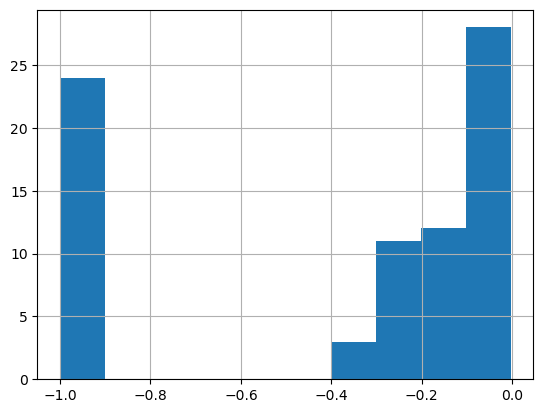

In [42]:
geodf_nexus[geodf_nexus["income"] <= 0]["income"].hist()

In [43]:
100 * len(geodf_nexus[geodf_nexus["income"] <= 0]["income"]) / len(geodf_nexus["income"])

0.0710091492557695

The amount of values equal or smaller than 0 in `income` column is less than 0.1%.

These samples are removed.

In [44]:
geodf_nexus = geodf_nexus[geodf_nexus["income"] > 0]

In [45]:
geodf_nexus.describe()

,cod_sector,Cod_municipio,cod_state,year,income,literacy,longevity
count,1.097670e+05,1.097670e+05,109767.000000,109767.0,109767.000000,109767.000000,109767.000000
mean,3.269860e+14,3.269860e+06,32.549701,2010.0,0.535508,0.889659,0.766502
std,1.042894e+14,1.042894e+06,10.433733,0.0,0.136567,0.105237,0.092059
min,1.100304e+14,1.100304e+06,11.000000,2010.0,0.002291,0.000000,0.083333
25%,2.408102e+14,2.408102e+06,24.000000,2010.0,0.436159,0.837802,0.716667
50%,3.106200e+14,3.106200e+06,31.000000,2010.0,0.532385,0.926233,0.766667
75%,3.536703e+14,3.536703e+06,35.000000,2010.0,0.616639,0.967843,0.833333
max,5.300108e+14,5.300108e+06,53.000000,2010.0,1.230630,1.000000,1.000000


#### Values bigger than 1
There are values above 1 in `income` column. It is important to analyze its histogram and fix data bigger than 1.

<Axes: >

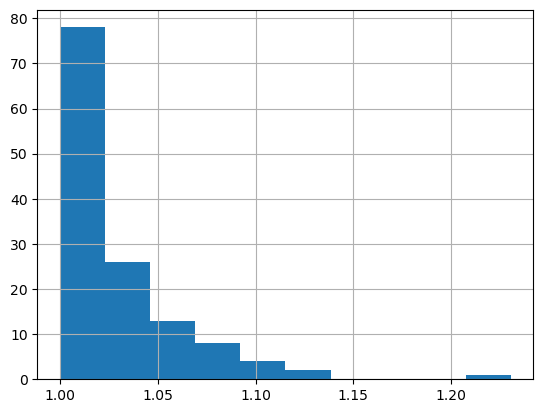

In [46]:
geodf_nexus[geodf_nexus["income"] > 1]["income"].hist()

In [47]:
100 * len(geodf_nexus[geodf_nexus["income"] > 1]["income"]) / len(geodf_nexus["income"])

0.12025472136434448

The amount of values bigger than 1 in `income` column is close to 0.1%.

These samples values are updated to `1.0`.

In [48]:
geodf_nexus["income"] = geodf_nexus.apply(lambda row: min(1.0, row["income"]), axis = "columns")

In [49]:
geodf_nexus.describe()

,cod_sector,Cod_municipio,cod_state,year,income,literacy,longevity
count,1.097670e+05,1.097670e+05,109767.000000,109767.0,109767.000000,109767.000000,109767.000000
mean,3.269860e+14,3.269860e+06,32.549701,2010.0,0.535472,0.889659,0.766502
std,1.042894e+14,1.042894e+06,10.433733,0.0,0.136435,0.105237,0.092059
min,1.100304e+14,1.100304e+06,11.000000,2010.0,0.002291,0.000000,0.083333
25%,2.408102e+14,2.408102e+06,24.000000,2010.0,0.436159,0.837802,0.716667
50%,3.106200e+14,3.106200e+06,31.000000,2010.0,0.532385,0.926233,0.766667
75%,3.536703e+14,3.536703e+06,35.000000,2010.0,0.616639,0.967843,0.833333
max,5.300108e+14,5.300108e+06,53.000000,2010.0,1.000000,1.000000,1.000000


### Clear based on literacy column
There are values equal to 0 in `literacy` column. It is important to analyze its histogram and fix data equal to 0.


<Axes: >

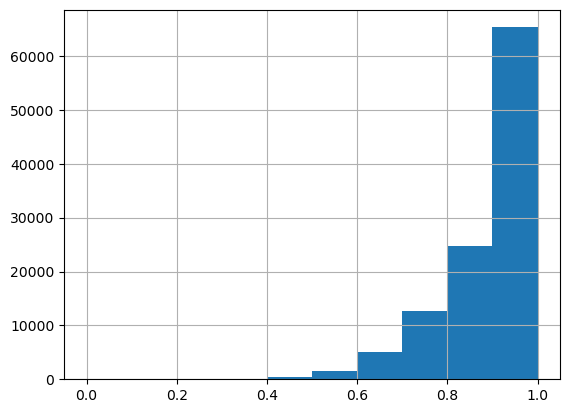

In [50]:
geodf_nexus["literacy"].hist()

In [51]:
100 * len(geodf_nexus[geodf_nexus["literacy"] == 0]["literacy"]) / len(geodf_nexus["literacy"])

0.001822041232793098

The amount of values equal to 0 in `literacy` column is negligible.

These samples are removed.

In [52]:
geodf_nexus = geodf_nexus[geodf_nexus["literacy"] > 0]

In [53]:
geodf_nexus.describe()

,cod_sector,Cod_municipio,cod_state,year,income,literacy,longevity
count,1.097650e+05,1.097650e+05,109765.000000,109765.0,109765.000000,109765.000000,109765.000000
mean,3.269826e+14,3.269826e+06,32.549365,2010.0,0.535477,0.889676,0.766504
std,1.042874e+14,1.042874e+06,10.433531,0.0,0.136430,0.105169,0.092055
min,1.100304e+14,1.100304e+06,11.000000,2010.0,0.002291,0.050000,0.083333
25%,2.408102e+14,2.408102e+06,24.000000,2010.0,0.436162,0.837805,0.716667
50%,3.106200e+14,3.106200e+06,31.000000,2010.0,0.532387,0.926234,0.766667
75%,3.536703e+14,3.536703e+06,35.000000,2010.0,0.616646,0.967843,0.833333
max,5.300108e+14,5.300108e+06,53.000000,2010.0,1.000000,1.000000,1.000000


## Store dataset

In [54]:
# geodf_nexus = geodf_nexus[[
#     "cod_sector",
#     "Cod_municipio",
#     "cod_state",
#     "TIPO",
#     "year",
#     "income",
#     "literacy",
#     "longevity",
#   ]]

In [55]:
# gerado por mim
geodf_nexus[geodf_nexus.cod_sector.isin([110030405000001, 110030405000002, 110030405000003, 110030405000004, 110030405000005])]

,cod_sector,Cod_municipio,cod_state,TIPO,year,income,literacy,longevity,geometry
1721,110030405000001,1100304,11,URBANO,2010,0.800035,0.996329,0.800000,"POLYGON ((-6694800.911 -1429885.364, -6694656...."
1722,110030405000002,1100304,11,URBANO,2010,0.727118,0.979336,0.766667,"POLYGON ((-6694910.447 -1430379.589, -6694777...."
1723,110030405000003,1100304,11,URBANO,2010,0.732076,0.964231,0.833333,"POLYGON ((-6695004.302 -1429829.110, -6694800...."
1724,110030405000004,1100304,11,URBANO,2010,0.787907,0.993087,0.766667,"POLYGON ((-6694625.032 -1429016.066, -6694180...."
1725,110030405000005,1100304,11,URBANO,2010,0.642104,0.947658,0.733333,"POLYGON ((-6695544.273 -1428781.091, -6695297...."


In [56]:
#antes printado no notebook
geodf_nexus.head()

,cod_sector,Cod_municipio,cod_state,TIPO,year,income,literacy,longevity,geometry
1721,110030405000001,1100304,11,URBANO,2010,0.800035,0.996329,0.800000,"POLYGON ((-6694800.911 -1429885.364, -6694656...."
1722,110030405000002,1100304,11,URBANO,2010,0.727118,0.979336,0.766667,"POLYGON ((-6694910.447 -1430379.589, -6694777...."
1723,110030405000003,1100304,11,URBANO,2010,0.732076,0.964231,0.833333,"POLYGON ((-6695004.302 -1429829.110, -6694800...."
1724,110030405000004,1100304,11,URBANO,2010,0.787907,0.993087,0.766667,"POLYGON ((-6694625.032 -1429016.066, -6694180...."
1725,110030405000005,1100304,11,URBANO,2010,0.642104,0.947658,0.733333,"POLYGON ((-6695544.273 -1428781.091, -6695297...."


In [57]:
geodf_nexus.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 109765 entries, 1721 to 316572
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   cod_sector     109765 non-null  int64   
 1   Cod_municipio  109765 non-null  int64   
 2   cod_state      109765 non-null  int64   
 3   TIPO           109765 non-null  object  
 4   year           109765 non-null  int64   
 5   income         109765 non-null  float64 
 6   literacy       109765 non-null  float64 
 7   longevity      109765 non-null  float64 
 8   geometry       109765 non-null  geometry
dtypes: float64(3), geometry(1), int64(4), object(1)
memory usage: 8.4+ MB


In [58]:
geodf_nexus.to_csv("../data/processed/NEXUS_data_2010.csv", index = False)

In [59]:
geodf_nexus_backup = geodf_nexus.copy()

In [60]:
geodf_nexus

,cod_sector,Cod_municipio,cod_state,TIPO,year,income,literacy,longevity,geometry
1721,110030405000001,1100304,11,URBANO,2010,0.800035,0.996329,0.800000,"POLYGON ((-6694800.911 -1429885.364, -6694656...."
1722,110030405000002,1100304,11,URBANO,2010,0.727118,0.979336,0.766667,"POLYGON ((-6694910.447 -1430379.589, -6694777...."
1723,110030405000003,1100304,11,URBANO,2010,0.732076,0.964231,0.833333,"POLYGON ((-6695004.302 -1429829.110, -6694800...."
1724,110030405000004,1100304,11,URBANO,2010,0.787907,0.993087,0.766667,"POLYGON ((-6694625.032 -1429016.066, -6694180...."
1725,110030405000005,1100304,11,URBANO,2010,0.642104,0.947658,0.733333,"POLYGON ((-6695544.273 -1428781.091, -6695297...."
...,...,...,...,...,...,...,...,...,...
316568,530010805300152,5300108,53,RURAL,2010,0.642797,0.941026,0.666667,"POLYGON ((-5320035.961 -1798443.288, -5320038...."
316569,530010805300153,5300108,53,URBANO,2010,0.855060,0.997175,0.783333,"POLYGON ((-5322368.326 -1788520.884, -5322163...."
316570,530010805300154,5300108,53,URBANO,2010,0.968965,1.000000,0.783333,"POLYGON ((-5323242.985 -1788724.011, -5323148...."
316571,530010805300155,5300108,53,URBANO,2010,0.892159,1.000000,0.733333,"POLYGON ((-5323028.958 -1788002.264, -5322483...."


# Notebook 3

# Select Clusters
## Description
This notebook draws a grid over the NEXUS area map and selects clusters formed by multiple census tracts.
## Inputs
`NEXUS_data_2010.csv`: dataset containing the geographic data and indicator target values of each census tract within the NEXUS area.
## Outputs

# Configs

## Libraries

In [61]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, Polygon
from shapely.wkt import loads, dumps
from tqdm import tqdm

In [62]:
import utils.plot_utils

In [63]:
# import sys
# sys.path.append("/content/drive/Shareddrives/NEXUS paper - TCC/codes/utils/")
# import plot_utils

## Projection constants

In [64]:
MERCATOR_CRS = "EPSG:3857"  # Mercator projection CRS.
METRIC_CRS = {"proj":"cea"} # Metric CRS. Useful for calculations
WGS84_CRS = "EPSG:4326"     # World Geodetic System
SIRGAS_CRS = "EPSG:4674"    # SIRGAS 2000, a projection for LATAM

PLOT_CRS = MERCATOR_CRS

# Execution

## Read input data

In [65]:
#geodf_nexus = gpd.read_file("../data/interim/NEXUS_data_2010.csv", encoding = "iso-8859-1")
#geodf_nexus = geodf_nexus.set_crs(MERCATOR_CRS)

In [66]:
geodf_nexus = geodf_nexus.to_crs(METRIC_CRS)

In [67]:
geodf_nexus = geodf_nexus.astype({
    "cod_sector": "int64",
    "income": "float64",
    "literacy": "float64",
    "longevity": "float64"
  })

In [68]:
geodf_nexus = geodf_nexus[["cod_sector", "year", "income", "literacy", "longevity", "geometry"]]

In [69]:
geodf_nexus.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 109765 entries, 1721 to 316572
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   cod_sector  109765 non-null  int64   
 1   year        109765 non-null  int64   
 2   income      109765 non-null  float64 
 3   literacy    109765 non-null  float64 
 4   longevity   109765 non-null  float64 
 5   geometry    109765 non-null  geometry
dtypes: float64(3), geometry(1), int64(2)
memory usage: 5.9 MB


In [70]:
geodf_nexus.head()

,cod_sector,year,income,literacy,longevity,geometry
1721,110030405000001,2010,0.800035,0.996329,0.800000,"POLYGON ((-6694800.911 -1397290.661, -6694656...."
1722,110030405000002,2010,0.727118,0.979336,0.766667,"POLYGON ((-6694910.447 -1397758.004, -6694777...."
1723,110030405000003,2010,0.732076,0.964231,0.833333,"POLYGON ((-6695004.302 -1397237.465, -6694800...."
1724,110030405000004,2010,0.787907,0.993087,0.766667,"POLYGON ((-6694625.032 -1396468.607, -6694180...."
1725,110030405000005,2010,0.642104,0.947658,0.733333,"POLYGON ((-6695544.273 -1396246.394, -6695297...."


## Create grid
This step objective is to draw a grid over the area of interest, where the size of each square is equal to the cluster image size ($size = 6.7 km$).



### Create grid: define grid limits
First, get the vertices coordinates that form the bounding box of the area of interest: `minx`, `maxx`, `miny` and `maxy`.

Each square in the grid is called by its upper left vertice indices as $(i,j)$.

<img src="https://drive.google.com/uc?export=view&id=1uZQxdN0N-YHUI8dI55bYdI1Pco29Q9lZ"/>
















The vertices horizontal coordinates are $x_i, i = 0, 1, ..., n$, while their vertical coordinates are $y_j, j = 0, 1, ..., m$.

The i-th coordinate along the horizontal axis is calculated as $x_i = i \cdot size + min_x$.

The j-th coordinate along the vertical axisis calculated as $y_j = j \cdot size + min_y$.

<img src="https://drive.google.com/uc?export=view&id=11b077Douq1OBFVxdym9-xUSjutvy3vgN"/>


In [71]:
min_x, min_y, max_x, max_y = geodf_nexus["geometry"].total_bounds

Plot the map bounding box, just for visualization.

In [72]:
bbox_vertices = [
    Point(min_x, min_y),
    Point(min_x, max_y),
    Point(max_x, max_y),
    Point(max_x, min_y)
]
bbox_vertices = gpd.GeoSeries(bbox_vertices, crs = METRIC_CRS)

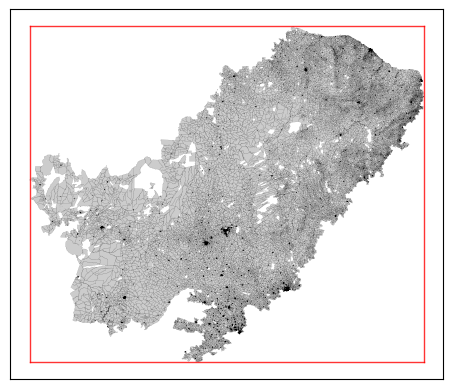

In [73]:
# plt.figure(figsize = (10, 10))
ax = plt.subplot(1, 1, 1)
utils.plot_utils.plot_map(ax, geodf_nexus)
utils.plot_utils.plot_square(ax, bbox_vertices)
plt.show()

### Create grid: find census tracts clusters in grid
To assess where an arbitrary point $(x,y)$ resides in the grid, it is possible to calculate the i-th and j-th square it is in as follows:

$i = \lfloor \frac{x - min_x}{size}  \rfloor$

$j = \lfloor \frac{y - min_y}{size} \rfloor$

For each census tract, it is necessary to calculate in which squares in the grid it resides. This is possible by obtaining the four vertices that form its bounding box and, then, calculating the four clusters squares in the grid that delimit that bounding box.

Those squares are
 $(i_{min}, j_{min})$,
 $(i_{min}, j_{max})$,
 $(i_{max}, j_{max})$ and 
 $(i_{max}, j_{min})$.

<img src="https://drive.google.com/uc?export=view&id=1KrLNsN4H59xN92tTdHdV1JJ2olTerxip"/>

In [74]:
cluster_image_lenght = 9e3 # 6.7e3

In [75]:
# from shapely.geometry import MultiPolygon

# # Supondo que gdf seja seu GeoDataFrame
# gdf = geodf_nexus.copy()
# gdf['geometry'] = gdf['geometry'].apply(lambda x: MultiPolygon([x]) if x.type == 'Polygon' else x)

In [76]:
def calculate_bounding_squares(
        geometry, # shapely.geometry.multipolygon.MultiPolygon
        size: float,
        min_x: float,
        min_y: float
    ):
    """
        Take a MultiPolygon and find in which grid squares its bounding box resides. 
    """
    cluster_min_x, cluster_min_y, cluster_max_x, cluster_max_y = geometry.bounds

    i_min = np.floor((cluster_min_x - min_x) / size).astype(int)
    i_max = np.floor((cluster_max_x - min_x) / size).astype(int)
    j_min = np.floor((cluster_min_y - min_y) / size).astype(int)
    j_max = np.floor((cluster_max_y - min_y) / size).astype(int)
    
    return [i_min, j_min, i_max, j_max]

In [77]:
geodf_nexus[["i_min", "j_min", "i_max", "j_max"]] = geodf_nexus.apply(
    lambda row: calculate_bounding_squares(
        row["geometry"],
        cluster_image_lenght,
        min_x,
        min_y
      ),
      axis = "columns",
      result_type = "expand"
    )

### Create grid: calculate area composition of each square

First, calculate the portion of each census tract in every cluster square in the grid.

In [78]:
def create_square_polygon_from_coordinate_indices(
        i: np.int32,
        j: np.int32,
        size: float,
        min_x: float, 
        min_y: float
    ):
    """
        Transform the indices of a cluster square (i,j) into a Polygon representing 
        that square, based on size, which is the side lenght of the square and min_x
        and min_y, which are coordinates of the bounding box of the area of interest.
    """
    x_left = i * size + min_x
    x_right = (i + 1) * size + min_x

    y_top = j * size + min_y
    y_bottom = (j + 1) * size + min_y

    vertices = [
            Point(x_left, y_top),
            Point(x_left, y_bottom),
            Point(x_right, y_bottom),
            Point(x_right, y_top)
    ]

    return Polygon([(point.x, point.y) for point in vertices])

In [79]:
def calculate_tract_inner_squares_area_portion(
        census_tract: pd.core.series.Series,
        size: float,
        min_x: float, 
        min_y: float
    ):
    """
        Take a census tract and find out in which cluster squares it is inside, by
        taking the intersection of the tract polygon and the squares and calculating
        the portion of the square area that is composed by that tract. This value is
        stored in a dictionary specific for that census tract (cod_sector), for each
        cluster square (i,j).
    """
    try:
        tract_portion_in_squares = {}
        tract_polygon = census_tract["geometry"]
        for i in range(census_tract["i_min"], census_tract["i_max"] + 1):
            for j in range(census_tract["j_min"], census_tract["j_max"] + 1):
                square_polygon = create_square_polygon_from_coordinate_indices(i, j, size, min_x, min_y)
                intersection_polygon = tract_polygon.intersection(square_polygon)
                portion = intersection_polygon.area / square_polygon.area
                if portion > 0:
                    tract_portion_in_squares[Point(i, j)] = portion

        return tract_portion_in_squares
    except:
        return None

In [ ]:
geodf_nexus["portions"] = geodf_nexus.apply(
  lambda row: calculate_tract_inner_squares_area_portion(
      row,
      cluster_image_lenght,
      min_x,
      min_y
  ),
  axis = "columns",
)

In [ ]:
geodf_nexus["portions"].isnull().values.any()

Then, create a single structure containing all the proportions by cluster square.

The structure is a dict `cluster_portions` where each key is a square that composes the grid, represented by the tuple `(i,j)`. Each value is another dict where keys are the `cod_sector` of a tract that composes that square and its value is the area portion of the square that is composed by the given tract.

There is an additional item for each square, `total`, which is the sum of all portions. Thus, it goes from `0.0` to `1.0`.

PS.: this can be further optimized using parallelism.

In [ ]:
cluster_portions = {}
for i in tqdm(range(geodf_nexus.shape[0])):
    census_tract = geodf_nexus.iloc[i]
    tract_portions = census_tract["portions"]
    for square, portion in tract_portions.items():
        square_portions = cluster_portions.setdefault(square, {})
        if len(square_portions) == 0:
            square_portions["total"] = 0.0
        square_portions[census_tract["cod_sector"]] = portion
        square_portions["total"] += portion
        cluster_portions[square] = square_portions

In [ ]:
len(cluster_portions)

## Find possible clusters
With the cluster squares that represent the grid and their area composition based on each census tract, it is possible to disregard those that present very large empty areas, based on an arbitrary threshold.

Then, for the remaining clusters, the indicator target values are calculated as the weighted average of the values, with the weights being the area proportions of each sector.

### Filter clusters by coverage area

Based on experimentation, there are 76365 possible clusters. The following table displays how the threshold affects that total due to filtering:

`thresold`   | clusters
-------------|-------------
1.00         | 47743
0.99         | 66762
0.95         | 68289
0.80         | 70446

In [ ]:
area_threshold = 1.00

In [ ]:
cluster_portions_filtered = {}
for square, portion in cluster_portions.items():
  if portion["total"] >= area_threshold:
    cluster_portions_filtered[square] = portion

In [ ]:
len(cluster_portions_filtered)

### Calculate target indicators

In [ ]:
clusters = []

indicators = ["income", "literacy", "longevity"]
for square, portion in tqdm(cluster_portions_filtered.items()):
  indicator_values = np.zeros(len(indicators))
  total = portion["total"]
  for cod_sector, area_percentage in portion.items():
    if cod_sector != "total":
      tract_indicator_values = geodf_nexus[geodf_nexus["cod_sector"] == cod_sector][indicators].values[0]
      indicator_values += np.array(tract_indicator_values) * area_percentage / total
  cluster_sample = dict(zip(indicators, indicator_values))
  cluster_sample["indices"] = square
  clusters.append(cluster_sample)

100%|██████████| 23719/23719 [02:35<00:00, 152.88it/s]


In [ ]:
df_clusters = pd.DataFrame.from_dict(clusters)

In [ ]:
df_clusters.head()

,income,literacy,longevity,indices
0,0.589932,0.934416,0.787581,POINT (8 143)
1,0.665026,0.934671,0.878097,POINT (8 142)
2,0.574890,0.872290,0.783350,POINT (9 142)
3,0.465565,0.820006,0.767197,POINT (9 143)
4,0.561065,0.863419,0.686567,POINT (10 147)


In [ ]:
df_clusters

,income,literacy,longevity,indices
0,0.589932,0.934416,0.787581,POINT (8 143)
1,0.665026,0.934671,0.878097,POINT (8 142)
2,0.574890,0.872290,0.783350,POINT (9 142)
3,0.465565,0.820006,0.767197,POINT (9 143)
4,0.561065,0.863419,0.686567,POINT (10 147)
...,...,...,...,...
23714,0.568743,0.920467,0.724278,POINT (164 108)
23715,0.573758,0.939253,0.672264,POINT (165 105)
23716,0.582426,0.904699,0.679219,POINT (163 104)
23717,0.624566,0.948119,0.770192,POINT (164 104)


## Store data

In [ ]:
df_clusters["geometry"] = df_clusters.apply(
    lambda cluster: create_square_polygon_from_coordinate_indices(
        cluster["indices"].x,
        cluster["indices"].y,
        cluster_image_lenght,
        min_x,
        min_y
    ),
    axis = "columns"
)

In [ ]:
df_clusters["WKT"] = df_clusters.apply(lambda cluster: dumps(cluster["geometry"]), axis = "columns")

In [ ]:
geodf_clusters = gpd.GeoDataFrame(
    df_clusters,
    crs = METRIC_CRS,
    geometry = [loads(mpoly) for mpoly in df_clusters["WKT"]])
geodf_clusters = geodf_clusters.to_crs(WGS84_CRS)

In [ ]:
geodf_clusters[["lon", "lat"]] = geodf_clusters.apply(
    lambda cluster: [cluster["geometry"].centroid.x, cluster["geometry"].centroid.y],
    axis = "columns",
    result_type = "expand"
)

In [ ]:
geodf_clusters["country"] = "brazil"
geodf_clusters["year"] = 2010

In [ ]:
geodf_clusters_clean = geodf_clusters[[
    "country",
    "year",
    "lat",
    "lon",
    "income",
    "literacy",
    "longevity"
  ]]

In [ ]:
geodf_clusters_clean.describe()

,year,lat,lon,income,literacy,longevity
count,23719.0,23719.000000,23719.000000,23719.000000,23719.000000,23719.000000
mean,2010.0,-13.182300,-48.010099,0.488830,0.832228,0.736297
std,0.0,5.017138,5.824026,0.123602,0.118178,0.086876
min,2010.0,-24.937995,-60.688729,0.022813,0.114262,0.133333
25%,2010.0,-17.268157,-52.523043,0.383836,0.759397,0.696294
50%,2010.0,-13.305273,-47.672140,0.506226,0.858989,0.751613
75%,2010.0,-9.074964,-43.629721,0.591530,0.928337,0.792054
max,2010.0,-2.364476,-35.221490,1.000000,1.000000,1.000000


In [ ]:
geodf_clusters_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23719 entries, 0 to 23718
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    23719 non-null  object 
 1   year       23719 non-null  int64  
 2   lat        23719 non-null  float64
 3   lon        23719 non-null  float64
 4   income     23719 non-null  float64
 5   literacy   23719 non-null  float64
 6   longevity  23719 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.3+ MB


In [ ]:
geodf_clusters_clean.head()

,country,year,lat,lon,income,literacy,longevity
0,brazil,2010,-12.720897,-60.122790,0.589932,0.934416,0.787581
1,brazil,2010,-12.804297,-60.122790,0.665026,0.934671,0.878097
2,brazil,2010,-12.804297,-60.041942,0.574890,0.872290,0.783350
3,brazil,2010,-12.720897,-60.041942,0.465565,0.820006,0.767197
4,brazil,2010,-12.387559,-59.961093,0.561065,0.863419,0.686567


In [100]:
geodf_clusters_clean.to_csv(f"../data/processed/clusters_data_{cluster_image_lenght}km.csv", index = False)

In [101]:
geodf_clusters_clean.to_csv(f"../data/processed/clusters_data_{cluster_image_lenght}km.csv", index = False)

## Plot map

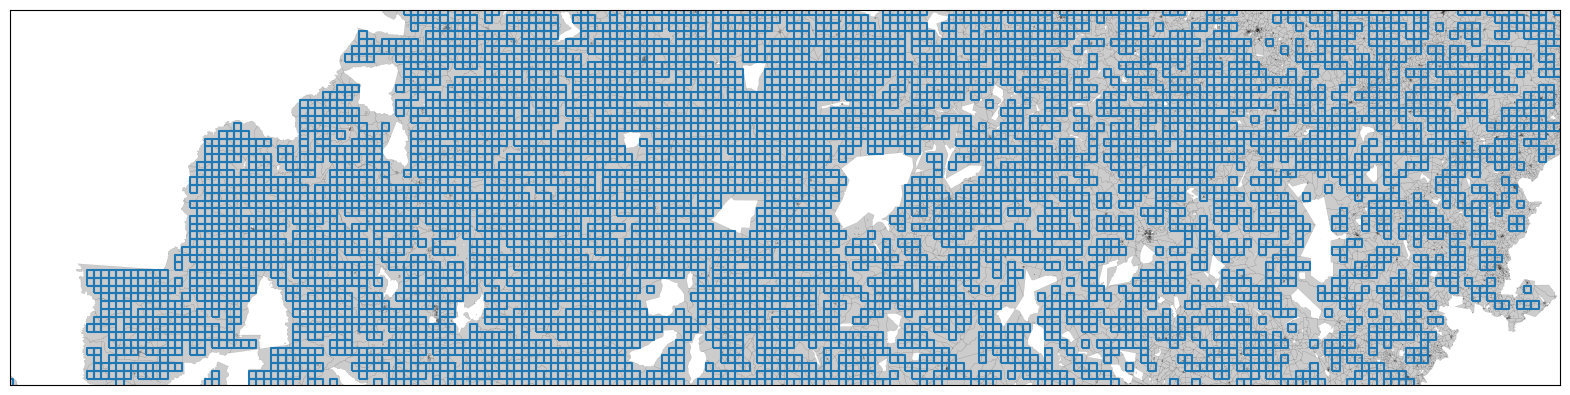

In [102]:
plt.figure(figsize = (20, 20))
ax = plt.subplot(1, 1, 1)
utils.plot_utils.plot_map(ax, geodf_nexus.to_crs(WGS84_CRS))
geodf_clusters.boundary.plot(ax = ax)
ax.set_xlim(-53, -36)
ax.set_ylim(-11, -7)
plt.show()

NameError: name 'plot_utils' is not defined

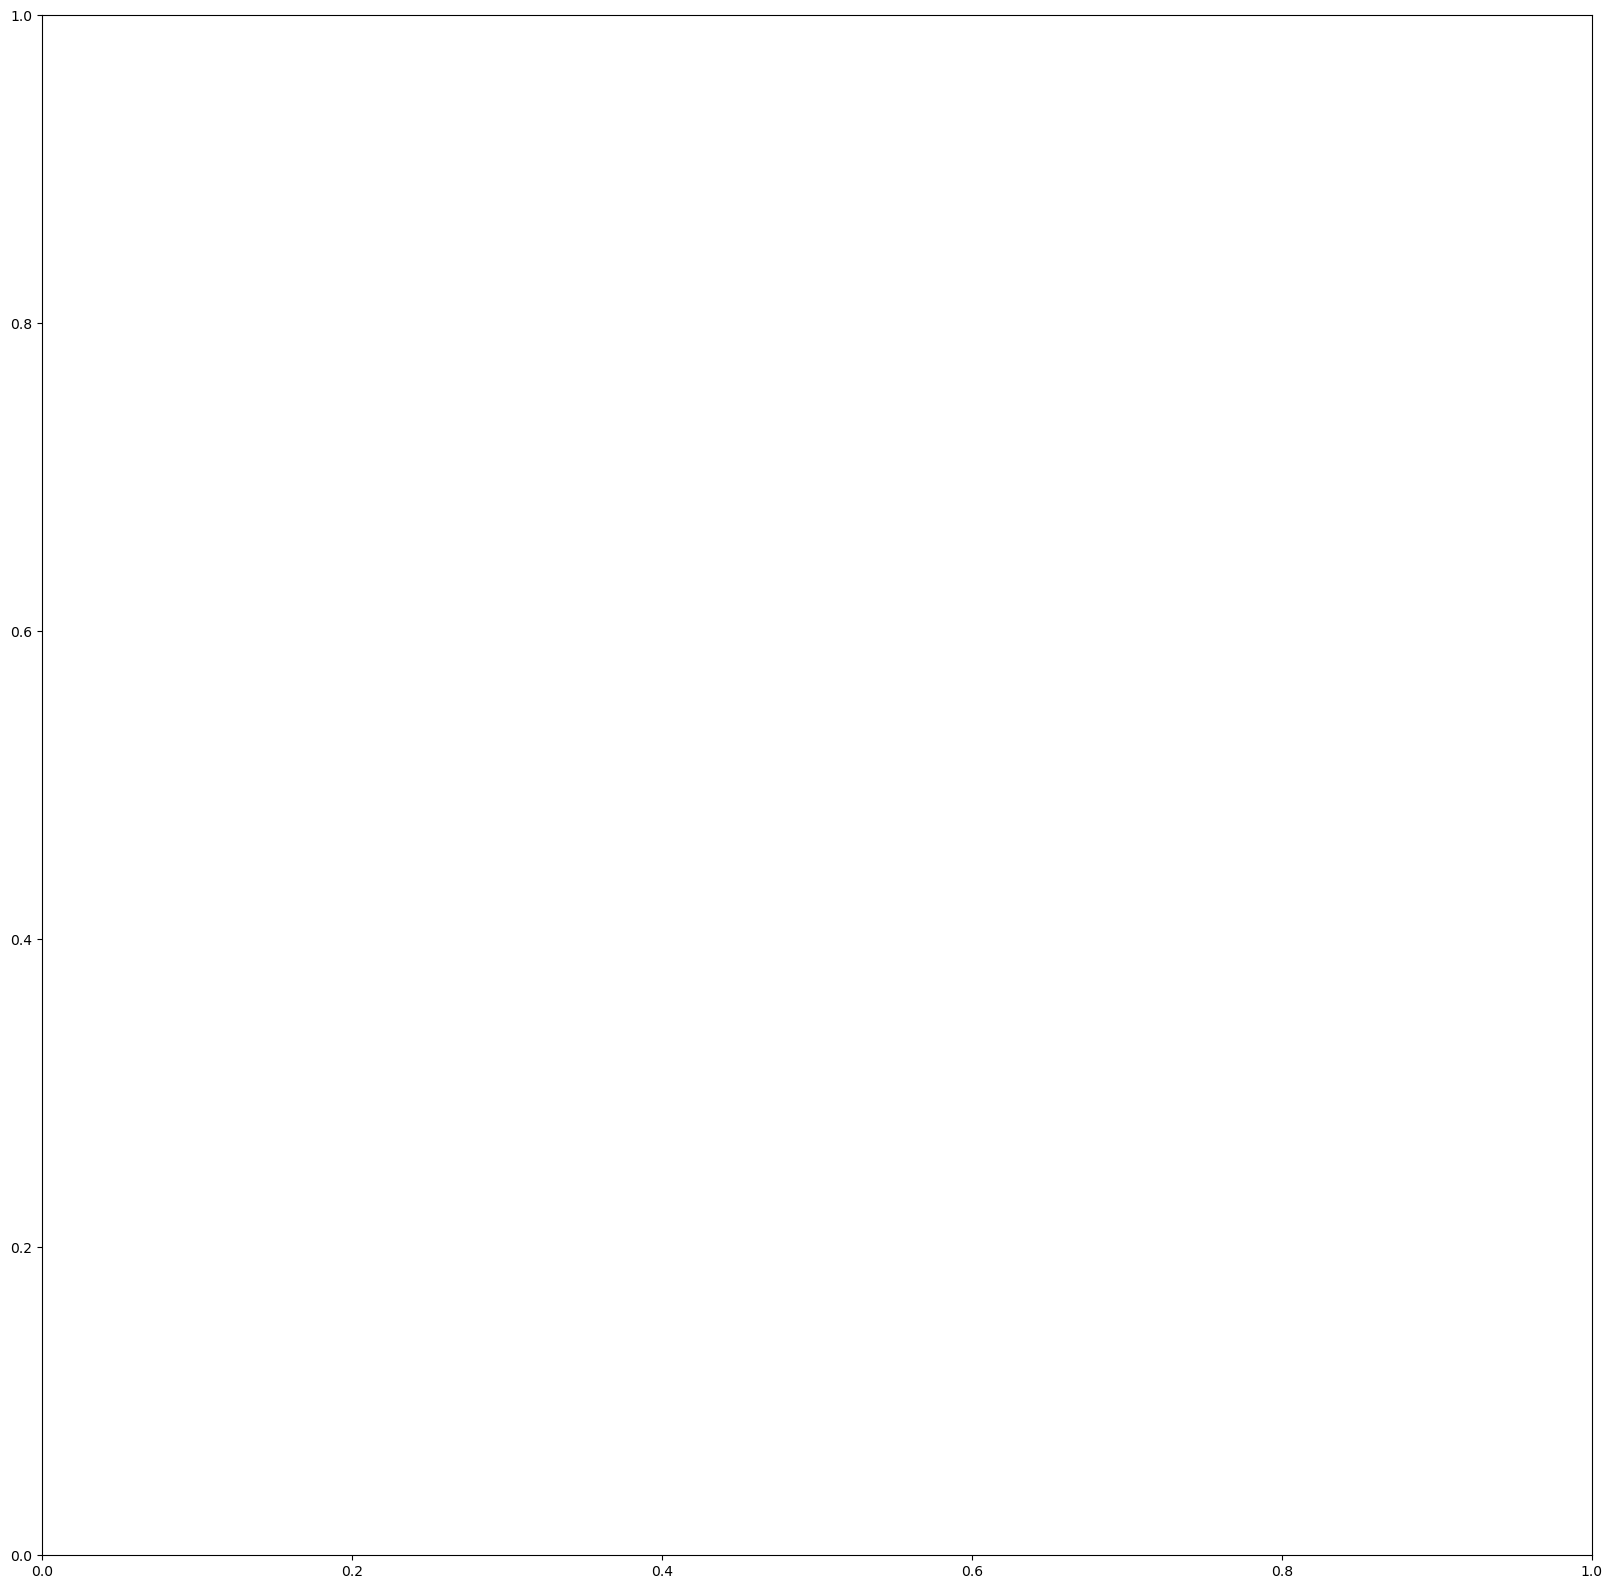

In [103]:
plt.figure(figsize = (20, 20))
ax = plt.subplot(1, 1, 1)
plot_utils.plot_map(ax, geodf_nexus.to_crs(WGS84_CRS))
geodf_clusters.boundary.plot(ax = ax)
ax.set_xlim(-53, -36)
ax.set_ylim(-11, -7)
plt.show()

In [ ]:
geodf_clusters_clean